<a href="https://colab.research.google.com/github/YujiSue/Research/blob/main/LitSurvey/NBRPReviewNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About this notebook

This  notebook includes all the code to export figures, tables, and supplementary data of the [review]().

# Setup

In [ ]:
#@title Load python modules
import os
import json
import numpy as np
import pandas as pd
import sqlite3

!pip install pycountry &> /dev/null
import pycountry
import plotly.express as px

from IPython.display import Image, display

# Install and load rpy2 to run R program on Colab.
!pip install rpy2==3.5.1 &> /dev/null
%load_ext rpy2.ipython

In [ ]:
%%R
#@title Install and load R libraries
library(ggplot2)
install.packages("BiocManager", ask = FALSE)
BiocManager::install("clusterProfiler", ask = FALSE)
BiocManager::install("org.Ce.eg.db", ask = FALSE)
BiocManager::install("pathview", ask = FALSE)
library(clusterProfiler)
library(org.Ce.eg.db)
library(pathview)

(as ‘lib’ is unspecified)







	‘/tmp/RtmpIgbTH0/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

































































	‘/tmp/RtmpIgbTH0/downloaded_packages’

  'dplyr', 'foreign', 'gargle', 'ggplot2', 'lubridate', 'pkgload', 'rappdirs',
  'timechange', 'uuid', 'vctrs', 'viridisLite', 'vroom', 'xfun', 'xml2'






















	‘/tmp/RtmpIgbTH0/downloaded_packages’

'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com









	‘/tmp/RtmpIgbTH0/downloaded_packages’



Please cite:

T Wu, E Hu, S Xu, M Chen, P Guo, Z Dai, T Feng, L Zhou, W Tang, L Zhan,
X Fu, S Liu, X Bo, and G Yu. clusterProfiler 4.0: A universal
enrichment tool for interpreting omics data. The Innovation. 2021,
2(3):100141

Attaching package: ‘clusterProfiler’



    filter






Attaching package: ‘generics’

In [ ]:
#@title Download required dataset
!mkdir -p /content/dataset
!mkdir -p /content/dataset/images

!curl -L -o /content/dataset/moirei.db "https://ys-ebase.net/research/nbrpreview/moirei.db"
!curl -L -o /content/dataset/worm.db "https://ys-ebase.net/research/nbrpreview/worm.db"

!curl -L -o /content/dataset/reference.db "https://raw.githubusercontent.com/YujiSue/Research/refs/heads/main/LitSurvey/Data/reference.db"
!curl -L -o /content/dataset/distributing.tsv "https://raw.githubusercontent.com/YujiSue/Research/refs/heads/main/LitSurvey/Data/distributing.tsv"
!curl -L -o /content/dataset/requests.tsv "https://raw.githubusercontent.com/YujiSue/Research/refs/heads/main/LitSurvey/Data/requests.tsv"
!curl -L -o /content/dataset/shipping.tsv "https://raw.githubusercontent.com/YujiSue/Research/refs/heads/main/LitSurvey/Data/shipping.tsv"


In [ ]:
#@title Open database files

refdb = sqlite3.connect('/content/dataset/reference.db')
refcur = refdb.cursor()
moirdb = sqlite3.connect('/content/dataset/moirei.db')
moircur = moirdb.cursor()
wormdb = sqlite3.connect('/content/dataset/worm.db')
wormcur = wormdb.cursor()

# Figures & Tables

In [ ]:
#@title Available alleles/strains
strainDF = pd.read_csv('/content/dataset/distributing.tsv', sep="\t", header=None)
strainDF.columns=["Name", "Type"]
display(strainDF.groupby("Type").size().reset_index(name="Alleles/Strains").sort_values("Alleles/Strains", ascending=False).style.hide(axis="index"))

Type,Alleles/Strains
mutant,13386
balancer,69
Cre,43
tau,14
a-syn,8


In [ ]:
#@title Gene annotation of each mutant
mutants = strainDF.loc[strainDF["Type"] == 'mutant', "Name"].to_list()
m2g = {}
mquery = ",".join(f"'{m}'" for m in mutants)
wormcur.execute(f"SELECT mutation.name,gene.gid,gene.type,gene.name FROM gene INNER JOIN mutation ON(gene.chromosome=mutation.chromosome and gene.start<=mutation.end and mutation.start<=gene.end) WHERE mutation.name IN({mquery})")
res = wormcur.fetchall()
with open('/content/dataset/mutgenes.csv', 'w') as f:
  for record in res:
    if record[0] not in m2g:
      m2g[record[0]] = []
    m2g[record[0]].append(record[1])
    f.write(f"{int(record[0].replace('tm',''))},{record[0]},{record[1]},{record[2]},{record[3]}\n")
json.dump(m2g, open('/content/dataset/mut2genes.json', 'w'))

In [ ]:
#@title Correspondence between mutations and deleted genes
#@markdown Note: Some mutations span multiple genes.
mutantDF = pd.read_csv('/content/dataset/mutgenes.csv', header=None)
mutantDF.columns = ['AlleleID', 'Mutant', 'GeneID', 'Type', 'Symbol']
display(mutantDF
        .sort_values("AlleleID")[["Mutant", "GeneID", "Symbol"]]
        .head(25)
        .style.hide(axis="index"))

Mutant,GeneID,Symbol
tm232,WBGene00006818,unc-86
tm233,WBGene00022666,ZK154.4
tm234,WBGene00198711,C54C6.9
tm234,WBGene00000248,ben-1
tm235,WBGene00001470,baz-2
tm237,WBGene00015934,ceh-48
tm238,WBGene00007984,irx-1
tm238,WBGene00197364,C36F7.14
tm239,WBGene00202458,C33D12.17
tm239,WBGene00000452,ceh-31


In [ ]:
#@title Proportion of genes mutated in our resources
#
type_labels = []
gene_counts = []
wormcur.execute("SELECT const.label,count(*) FROM gene INNER JOIN const ON(gene.type=const.value and const.target='gene.type') WHERE 0 < gene.type and gene.type < 128 GROUP BY gene.type ORDER BY gene.type")
res = wormcur.fetchall()
for record in res:
  type_labels.append(record[0])
  gene_counts.append(record[1])
#
collection_rate = (mutantDF.loc[(mutantDF['Type']>0) & (mutantDF['Type']<128),:]
             .groupby("Type")["GeneID"].nunique()
             .reset_index(name="Mutated")
             .sort_values("Type"))
collection_rate['Type'] = type_labels
collection_rate['Total'] = gene_counts
display(collection_rate.style.hide(axis="index"))
collection_rate.to_csv('/content/dataset/collected.csv', index=False)

Type,Mutated,Total
protein coding,11252,19984
non-coding,8234,25536
pseudogene,965,2131
transposon,124,365


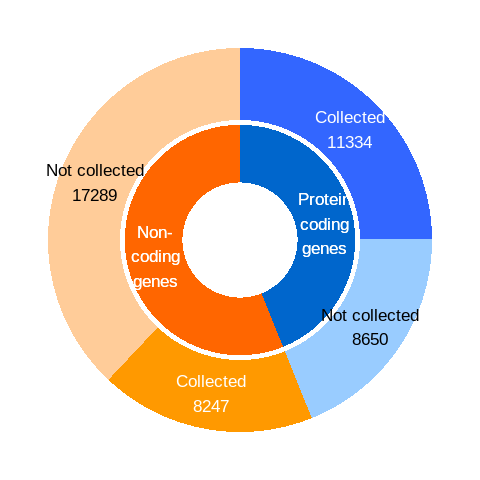

In [ ]:
%%R
#@title Double donut chart

# Inner radius
ri<-c(0.6, 1.2)
# Outer radius
ro<-c(1.25, 2.0)
# Label text size
txtsz<-6

# Inner label
ilabel<-rep(c("Protein coding genes","Non-coding genes"),c(2,2))
ilabel<-factor(ilabel, levels=unique(ilabel))
# Outer label
olabel<-rep(c("Collected","Not collected"),2)
olabel<-factor(olabel, levels=unique(olabel))
#
df<-read.csv("/content/dataset/collected.csv",row.names=1)
value<-c(df[1,1],df[1,2]-df[1,1],df[2,1],df[2,2]-df[2,1])

#
ivalue<-cumsum(unname(tapply(value, ilabel, sum)))
ovalue<-cumsum(value)

# Make dataframe
df<-data.frame(
    value=value, # original values
    oxmin=rep(ro[1],4), # outer chart range (r)
    oxmax=rep(ro[2],4),
    oymin=c(0,head(ovalue,-1)),  # outer chart range (arg)
    oymax=ovalue,
    olabel=olabel, # outer chart label
    ixmin=rep(0.6,4), # inner chart range (r)
    ixmax=rep(1.2,4),
    iymin=rep(c(0,head(ivalue, -1)),c(2,2)), # inner chart range (arg)
    iymax=rep(ivalue,c(2,2)),
    ilabel=ilabel,  # inner chart label
    label=paste(ilabel,olabel,sep=" "), # grouping label
    nlabel=paste(olabel,value,sep="\n")  # indicator label
)

# Draw chart
ggplot(df) +
  geom_rect(aes(xmin = oxmin, xmax = oxmax, ymin = oymin, ymax = oymax, fill = label)) +
  geom_rect(aes(xmin = ixmin, xmax = ixmax, ymin = iymin, ymax = iymax, fill = ilabel)) +
  geom_text(aes(x=(oxmin+oxmax)/2,y=(oymin+oymax)/2,label=nlabel, color=olabel), size=txtsz) +
  geom_text(aes(x=(ixmin+ixmax)/2,y=(iymin+iymax)/2,label=gsub("-","-\n",gsub("\\s+", "\n", ilabel))), size=txtsz, color="white") +
  scale_fill_manual(
      values = c(
          "Protein coding genes" = "#0066CC",
          "Non-coding genes" = "#FF6600",
          "Protein coding genes Collected" = "#3366FF",
          "Protein coding genes Not collected" = "#99CCFF",
          "Non-coding genes Collected" = "#FF9900",
          "Non-coding genes Not collected" = "#FFCC99"
      )
  ) +
  scale_color_manual(
      values = c("Collected" = "white", "Not collected" = "black")
  ) +
  coord_polar(theta = "y") + xlim(0, ro[2])+theme_void()+ theme(legend.position = "none")


In [ ]:
#@title WormBase Gene ID => Entrez ID
genes = list(set(mutantDF['GeneID'].tolist()))
gquery = ','.join(f"'{g}'" for g in genes)
wormcur.execute(f"SELECT gene.gid,xref.refid FROM xref INNER JOIN gene on xref.dbid=gene.id WHERE xref.type=1 AND xref.ref='ncbi' and gene.gid in({gquery})")
res = wormcur.fetchall()
with open('/content/dataset/entrezID.csv', 'w') as f:
  for record in res:
    f.write(f"{record[0]},{record[1]}\n")

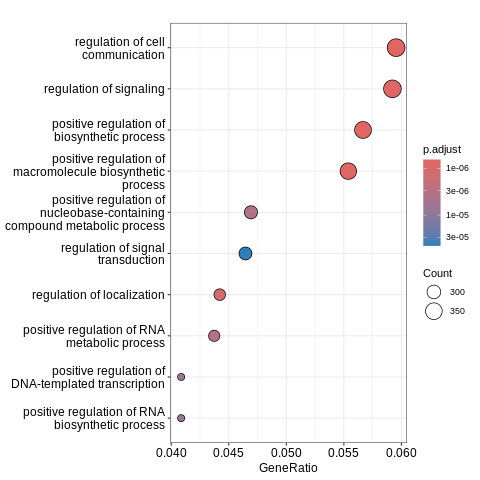

In [ ]:
#@title GO analysis
%%R
setwd('/content/dataset')
gids <- read.csv('/content/dataset/entrezID.csv',header=F)
gids <- gids[,2]
gos <- enrichGO(
            gene = gids,
            OrgDb = org.Ce.eg.db,
            ont = 'ALL',
            minGSSize = 10,
            maxGSSize = 500,
            pAdjustMethod = "BH",
            qvalueCutoff = 0.05)
write.csv(gos,'/content/dataset/goa.csv')
dot <- dotplot(gos, showCategory = 10)
print(dot)

In [ ]:
#@title Export table
#
gm = {}
for idx,row in mutantDF.iterrows():
  if row["GeneID"] not in gm:
    gm[row["GeneID"]] = []
  gm[row["GeneID"]].append(int(row["Mutant"].strip()[2:]))
#
idconv = {}
eidDF = pd.read_csv('/content/dataset/entrezID.csv',header=None)
for idx,row in eidDF.iterrows():
  if str(row[1]) not in idconv:
    idconv[str(row[1])] = row[0]
#
wgids = []
wmuts = []
#
goDF = pd.read_csv('/content/dataset/goa.csv',header=0)
gowormDF = goDF[["ID", "ONTOLOGY", "Description", "geneID"]]
eids = goDF["geneID"].to_list()
for row in eids:
  wgid = []
  wmut = []
  ids = row.split('/')
  for eid in ids:
    if eid in idconv:
      wgid.append(idconv[eid])
  wgid = sorted(list(set(wgid)))
  for wg in wgid:
    wmut.extend(gm[wg])
  wmut = sorted(list(set(wmut)))
  wmut = [f"tm{num}" for num in wmut]
  wgids.append(','.join(wgid))
  wmuts.append(','.join(wmut))
#
gowormDF["WormGene"] = wgids
gowormDF["Mutant"] = wmuts
gowormDF.to_csv('wormgo.tsv', sep="\t")
display(gowormDF.head(20).style.hide(axis="index").set_properties(**{"text-align": "left"}))

/tmp/ipython-input-2464413881.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gowormDF["WormGene"] = wgids
/tmp/ipython-input-2464413881.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gowormDF["Mutant"] = wmuts


In [ ]:
#@title WormBase Gene ID => KEGG CEL ID
wormcur.execute(f"SELECT gene.gid,synonym.name FROM synonym INNER JOIN gene ON synonym.gene=gene.id where gene.gid in({gquery})")
res = wormcur.fetchall()
with open('/content/dataset/keggID.csv', 'w') as f:
  for record in res:
    f.write(f"{record[0]},CELE_{record[1]}\n")

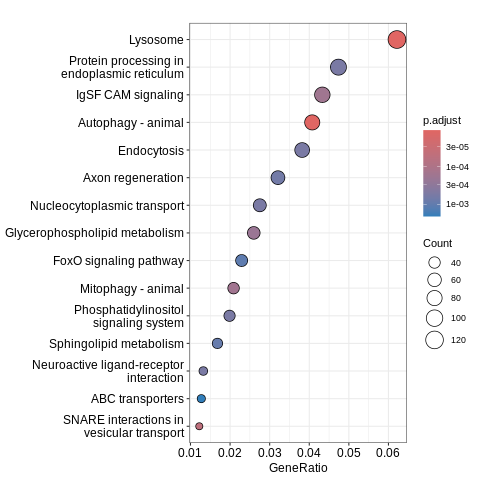

In [ ]:
#@title KEGG pathway analysis
%%R
setwd('/content/dataset')
kgids <- read.csv('/content/dataset/keggID.csv',header=F)
kgids <- kgids[,2]
kegg <- enrichKEGG(
            gene = kgids,
            organism = 'cel',
            minGSSize = 10,
            maxGSSize = 500,
            pAdjustMethod = "BH",
            qvalueCutoff = 0.05)
write.csv(kegg,'/content/dataset/kegga.csv')
dot <- dotplot(kegg, showCategory = 15)
print(dot)

In [ ]:
#@title Export table
#
gm = {}
for idx,row in mutantDF.iterrows():
  if row["GeneID"] not in gm:
    gm[row["GeneID"]] = []
  gm[row["GeneID"]].append(int(row["Mutant"].strip()[2:]))
#
idconv = {}
keggidDF = pd.read_csv('/content/dataset/keggID.csv',header=None)
for idx,row in keggidDF.iterrows():
  if str(row[1]) not in idconv:
    idconv[str(row[1])] = row[0]
#
wgids = []
wmuts = []
#
keggDF = pd.read_csv('/content/dataset/kegga.csv',header=0)
keggwormDF = keggDF[["ID", "Description", "geneID"]]
keggids = keggDF["geneID"].to_list()
for row in keggids:
  wgid = []
  wmut = []
  ids = row.split('/')
  for keggid in ids:
    if keggid in idconv:
      wgid.append(idconv[keggid])
  wgid = sorted(list(set(wgid)))
  for wg in wgid:
    wmut.extend(gm[wg])
  wmut = sorted(list(set(wmut)))
  wmut = [f"tm{num}" for num in wmut]
  wgids.append(','.join(wgid))
  wmuts.append(','.join(wmut))
#
keggwormDF["WormGene"] = wgids
keggwormDF["Mutant"] = wmuts
keggwormDF.to_csv('wormkegg.tsv', sep="\t")
display(keggwormDF.head(20).style.hide(axis="index").set_properties(**{"text-align": "left"}))

/tmp/ipython-input-2858795131.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  keggwormDF["WormGene"] = wgids
/tmp/ipython-input-2858795131.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  keggwormDF["Mutant"] = wmuts


ID,Description,geneID,WormGene,Mutant
cel04142,Lysosome,CELE_F55A12.7/CELE_F02E8.3/CELE_Y105E8A.9/CELE_F29G9.3/CELE_Y71H2B.10/CELE_T20B5.1/CELE_W09G10.4/CELE_R11A5.1/CELE_F53H8.1/CELE_W04G3.4/CELE_Y57G11C.13/CELE_B0252.2/CELE_ZK455.4/CELE_W03G1.7/CELE_H22K11.1/CELE_R12H7.2/CELE_R07B7.1/CELE_C07H6.6/CELE_C01G8.2/CELE_T10H4.12/CELE_F44C4.3/CELE_C25B8.3/CELE_F32B5.8/CELE_M04G12.2/CELE_K04H4.6/CELE_R13A5.1/CELE_R160.1/CELE_F43E2.4/CELE_Y50E8A.16/CELE_ZK484.2/CELE_B0261.2/CELE_C03B1.12/CELE_F02E8.6/CELE_C07B5.5/CELE_EGAP2.3/CELE_F44C4.5/CELE_W03C9.3/CELE_F54E4.1/CELE_Y54F10AM.10/CELE_K11G12.4/CELE_K11G12.3/CELE_Y69A2AR.4/CELE_Y110A7A.12/CELE_T24F1.1/CELE_C05D11.2/CELE_T23D8.2/CELE_ZK637.8/CELE_K11D2.3/CELE_Y38F2AL.4/CELE_C26H9A.1/CELE_F46F11.5/CELE_Y38F2AL.3/CELE_T20D3.7/CELE_F59G1.3/CELE_F41E6.6/CELE_F09G8.2/CELE_C05C10.4/CELE_C06H2.6/CELE_C33G3.4/CELE_C34B7.2/CELE_C47A4.2/CELE_F02E9.7/CELE_F07H5.9/CELE_F11E6.1/CELE_F13D12.6/CELE_F13H10.3/CELE_F26C11.1/CELE_F27E5.1/CELE_F32H5.1/CELE_F42A8.3/CELE_F54F3.3/CELE_F57F5.1/CELE_H32K16.1/CELE_K08E7.1/CELE_K09A9.3/CELE_K09E4.4/CELE_K11D2.2/CELE_R10H10.7/CELE_T08G5.5/CELE_T08G11.1/CELE_T19B10.3/CELE_T20G5.1/CELE_T20G5.10/CELE_T22C8.2/CELE_T28H10.3/CELE_VF39H2L.1/CELE_Y16B4A.2/CELE_Y24F12A.2/CELE_Y49E10.20/CELE_Y51H1A.2/CELE_Y76A2B.6/CELE_ZK1128.8/CELE_B0303.9/CELE_C02B10.2/CELE_C13F10.2/CELE_C29E4.10/CELE_C30F8.2/CELE_C33C12.3/CELE_C33C12.8/CELE_F16H11.3/CELE_F41C3.5/CELE_F52E1.13/CELE_F55D10.1/CELE_F59E12.11/CELE_H14A12.3/CELE_K02D10.5/CELE_R04B3.2/CELE_T13B5.3/CELE_T14F9.1/CELE_T14F9.3/CELE_T27A1.5/CELE_W06B4.3/CELE_W07B8.1/CELE_W07B8.4/CELE_Y4C6B.6/CELE_Y37E11B.3/CELE_Y40D12A.2/CELE_Y55H10A.1/CELE_Y69A2AR.6/CELE_Y97E10AR.7/CELE_ZK6.7/CELE_Y87G2A.19,"WBGene00000150,WBGene00000157,WBGene00000158,WBGene00000159,WBGene00000160,WBGene00000161,WBGene00000162,WBGene00000163,WBGene00000164,WBGene00000166,WBGene00000192,WBGene00000211,WBGene00000212,WBGene00000213,WBGene00000216,WBGene00000217,WBGene00000533,WBGene00000537,WBGene00000540,WBGene00000783,WBGene00000784,WBGene00000786,WBGene00000788,WBGene00000789,WBGene00000799,WBGene00000846,WBGene00001082,WBGene00001812,WBGene00001817,WBGene00001819,WBGene00002583,WBGene00003053,WBGene00003561,WBGene00003828,WBGene00004020,WBGene00004092,WBGene00004271,WBGene00004313,WBGene00004314,WBGene00004876,WBGene00004877,WBGene00004878,WBGene00004959,WBGene00006414,WBGene00006516,WBGene00006633,WBGene00006768,WBGene00006829,WBGene00006912,WBGene00006916,WBGene00006919,WBGene00006920,WBGene00006931,WBGene00006933,WBGene00007055,WBGene00007056,WBGene00007331,WBGene00007390,WBGene00007904,WBGene00007912,WBGene00008123,WBGene00008531,WBGene00008560,WBGene00008706,WBGene00008741,WBGene00008774,WBGene00009146,WBGene00009192,WBGene00009347,WBGene00009627,WBGene00010062,WBGene00010204,WBGene00010421,WBGene00010671,WBGene00010701,WBGene00010722,WBGene00010769,WBGene00011225,WBGene00011625,WBGene00011629,WBGene00011832,WBGene00011867,WBGene00011872,WBGene00011923,WBGene00012144,WBGene00012150,WBGene00012445,WBGene00012497,WBGene00013039,WBGene00013093,WBGene00013578,WBGene00014234,WBGene00015130,WBGene00015327,WBGene00015742,WBGene00016207,WBGene00016258,WBGene00016335,WBGene00016340,WBGene00017532,WBGene00018271,WBGene00018700,WBGene00018877,WBGene00019126,WBGene00019196,WBGene00019305,WBGene00019867,WBGene00020471,WBGene00020507,WBGene00020509,WBGene00020837,WBGene00021058,WBGene00021070,WBGene00021072,WBGene00021160,WBGene00021376,WBGene00021503,WBGene00021952,WBGene00022077,WBGene00022402,WBGene00022642,WBGene00044260","tm327,tm344,tm408,tm495,tm599,tm609,tm612,tm617,tm762,tm890,tm908,tm920,tm935,tm1125,tm1249,tm1320,tm1369,tm1455,tm1487,tm1523,tm1528,tm1759,tm1792,tm1862,tm1892,tm1954,tm1974,tm1987,tm1992,tm2060,tm2225,tm2253,tm2339,tm2345,tm2367,tm2384,tm2388,tm2410,tm2472,tm2474,tm2476,tm2501,tm2504,tm2596,tm2742,tm2752,tm2866,tm2876,tm2912,tm2935,tm3181,tm3182,tm3188,tm3244,tm3300,tm3302,tm3314,tm3349,tm3352,tm3537,tm3544,tm3659,tm3718,tm3746,tm3776,tm3816,t

In [ ]:
#@title Recent requests and requested alleles/strains
df = pd.read_csv("/content/dataset/requests.tsv",sep="\t", header=None)
df.columns=["Year", "Requests", "Count"]
df2 = df.groupby("Year").agg(Requests=("Requests", "nunique"), Requested=("Count", "sum")).reset_index().rename(columns={"Requested": "Requested alleles/strains"})
display(df2.sort_values("Year").style.hide(axis="index"))

Year,Requests,Requested alleles/strains
2019,548,2018
2020,394,1552
2021,504,2032
2022,500,1766
2023,470,1731


In [ ]:
#@title Top 25 destination countries
df = pd.read_csv("/content/dataset/shipping.tsv",sep="\t", header=None)
df.columns=["Country", "Requested alleles/strains"]
display(df.sort_values("Requested alleles/strains", ascending=False).head(25).style.hide(axis="index").set_properties(**{"text-align": "left"}))


Country,Requested alleles/strains
USA,15259
China,4094
Japan,3116
Germany,1664
United Kingdom,1487
Canada,1429
South Korea,964
Taiwan,576
Switzerland,460
France,388


In [ ]:
#@title Distribution map (by country)

# Encode country name to three characters code
def to_iso3(name):
  try:
    return pycountry.countries.lookup(name).alpha_3
  except LookupError:
    print(name)
    return None

df["iso3"] = df["country"].apply(to_iso3)

# Draw figure
fig = px.choropleth(df,
                    locations="iso3",
                    color="count",
                    color_continuous_scale="YlOrRd",
                    projection="natural earth",
                    range_color=[0, 1000],
                    title="Shipments by country")

fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0})
fig.show()

In [ ]:
#@title Reference articles describing at least a strain of our resources
refcur.execute("SELECT count(*) FROM reference where label!='' AND note!=''")
res = refcur.fetchone()
print(f"Total: {res[0]} references.")
refcur.execute("SELECT id,title,author,journal,label,volume,issue,page,note FROM reference where label!='' AND note!=''")
res = refcur.fetchall()
with open('/content/dataset/reflist.tsv', 'w') as f:
  for record in res:
    f.write(f"{record[0]}\t\"{record[1].replace("\"","''")}\"\t{','.join(json.loads(record[2]))}\t{record[3]}\t{record[4]}\t{record[5]}\t{record[6]}\t{record[7]}\t{record[8]}\n")
#
refDF = pd.read_csv('/content/dataset/reflist.tsv', sep="\t", header=None)
refDF.columns = ["PubMed ID", "Title", "Author", "Journal", "Label", "Volume", "Issue", "Page", "Note"]
display(refDF.head(25).style.hide(axis="index").set_properties(**{"text-align": "left"}))

Total: 3930 references.


PubMed ID,Title,Author,Journal,Label,Volume,Issue,Page,Note
10694478,"Characterization of mutations induced by ethyl methanesulfonate, UV, and trimethylpsoralen in the nematode Caenorhabditis elegans.","Gengyo-Ando K,Mitani S",Biochemical and biophysical research communications,1999,269,1,64-9,Text mining: tm234
11604136,"C. elegans slit acts in midline, dorsal-ventral, and anterior-posterior guidance via the SAX-3/Robo receptor.","Hao JC,Yu TW,Fujisawa K,Culotti JG,Gengyo-Ando K,Mitani S,Moulder G,Barstead R,Tessier-Lavigne M,Bargmann CI",Neuron,2001,32,1,25-38,Text mining: tm307
12062106,"HEN-1, a secretory protein with an LDL receptor motif, regulates sensory integration and learning in Caenorhabditis elegans.","Ishihara T,Iino Y,Mohri A,Mori I,Gengyo-Ando K,Mitani S,Katsura I",Cell,2002,109,5,639-49,Text mining: tm501
12231504,A CaMK cascade activates CRE-mediated transcription in neurons of Caenorhabditis elegans.,"Kimura Y,Corcoran EE,Eto K,Gengyo-Ando K,Muramatsu MA,Kobayashi R,Freedman JH,Mitani S,Hagiwara M,Means AR,Tokumitsu H",EMBO reports,2002,3,10,962-6,Text mining: tm421
12702662,Translational control of maternal glp-1 mRNA by POS-1 and its interacting protein SPN-4 in Caenorhabditis elegans.,"Ogura K,Kishimoto N,Mitani S,Gengyo-Ando K,Kohara Y","Development (Cambridge, England)",2003,130,11,2495-503,Text mining: tm291
12761550,Chondroitin proteoglycans are involved in cell division of Caenorhabditis elegans.,"Mizuguchi S,Uyama T,Kitagawa H,Nomura KH,Dejima K,Gengyo-Ando K,Mitani S,Sugahara K,Nomura K",Nature,2003,423,6938,443-8,Text mining: tm546
12783787,"UNC-71, a disintegrin and metalloprotease (ADAM) protein, regulates motor axon guidance and sex myoblast migration in C. elegans.","Huang X,Huang P,Robinson MK,Stern MJ,Jin Y","Development (Cambridge, England)",2003,130,14,3147-61,"Text mining: tm347,tm353"
12819265,Distribution and movement of Caenorhabditis elegans on a thermal gradient.,"Yamada Y,Ohshima Y",The Journal of experimental biology,2003,206,Pt 15,2581-93,Text mining: tm268
12837290,"Role of Caenorhabditis elegans protein phosphatase type 1, CeGLC-7 beta, in metaphase to anaphase transition during embryonic development.","Sassa T,Ueda-Ohba H,Kitamura K,Harada S,Hosono R",Experimental cell research,2003,287,2,350-60,Text mining: tm301
14645848,Cell corpse engulfment mediated by C. elegans phosphatidylserine receptor through CED-5 and CED-12.,"Wang X,Wu YC,Fadok VA,Lee MC,Gengyo-Ando K,Cheng LC,Ledwich D,Hsu PK,Chen JY,Chou BK,Henson P,Mitani S,Xue D","Science (New York, N.Y.)",2003,302,5650,1563-6,Text mining: tm469


In [ ]:
#@title Top 25 journals in which our strains were described
#@markdown Note: Data summarized for the period from 1999 to 2023
refcur.execute("SELECT journal,count(*) FROM reference WHERE label!='' AND note!='' GROUP BY journal")
res = refcur.fetchall()
print(f"Total: {len(res)} jounals.")
refcur.execute("SELECT journal,count(*) FROM reference WHERE label!='' AND note!='' GROUP BY journal ORDER BY count(*) DESC limit 25")
res = refcur.fetchall()
with open('/content/dataset/journals.csv', 'w') as f:
  for record in res:
    f.write(f'"{record[0]}",{record[1]}\n')

journalDF = pd.read_csv('/content/dataset/journals.csv', header=None)
journalDF.columns = ["Journal", "Count"]
display(journalDF.style.hide(axis="index").set_properties(**{"text-align": "left"}))

Total: 3930 references.
> 369 jounals.


Journal,Count
PLoS genetics,343
Genetics,209
PloS one,166
eLife,156
"Development (Cambridge, England)",145
Proceedings of the National Academy of Sciences of the United States of America,142
Nature communications,142
Current biology : CB,125
Developmental biology,119
Cell reports,94


In [ ]:
#@title Top 25 most frequently used alleles/strains in research articles
ref_label = {}
used_alleles = {}
count = {}
for idx,row in refDF.iterrows():
  if row['Label'] not in ref_label:
    ref_label[row['Label']] = []
  ref_label[row['Label']].append(str(row['PubMed ID']))

  alleles = row['Note'].replace('Text mining: ', '').split(',')
  alleles = [a.strip() for a in alleles]
  used_alleles[str(row['PubMed ID'])] = alleles

  for a in alleles:
    if a in count:
      count[a] += 1
    else:
      count[a] = 1

characterizedDF = mutantDF[mutantDF["Symbol"].str.contains(r"^[a-z]+[-][0-9]+", regex=True)]

countDF = pd.DataFrame(list(count.items()))
countDF.columns = ['Allele', 'Count']
countDF = pd.merge(countDF, characterizedDF, left_on="Allele", right_on="Mutant")

display(countDF.sort_values('Count', ascending=False).head(30)[["Allele", "GeneID", "Symbol", "Count"]].style.hide(axis="index"))

Allele,GeneID,Symbol,Count
tm1200,WBGene00007624,hrde-1,82
tm1108,WBGene00001093,drp-1,75
tm1978,WBGene00020930,hlh-30,73
tm331,WBGene00001398,fat-6,71
tm1145,WBGene00000264,brc-1,58
tm1325,WBGene00004780,ser-7,54
tm776,WBGene00004930,sod-1,53
tm760,WBGene00004932,sod-3,51
tm1944,WBGene00019801,aak-1,50
tm1133,WBGene00001509,fzo-1,50


In [ ]:
#@title Orthologues of human genes and disease-related genes
codings = sorted(list(set(mutantDF[(mutantDF['Type']==1)]["GeneID"].tolist())))
ortho = {}
hgenes = []
#
wquery = ",".join(f"'{g}'" for g in codings)
#
moircur.execute(f"SELECT gid2,gid1 FROM ortholog WHERE taxon1=9606 AND taxon2=6239 AND gid2 in({wquery}) UNION SELECT gid1,gid2 FROM ortholog WHERE taxon2=9606 AND taxon1=6239 AND gid1 in({wquery})")
res = moircur.fetchall()
for record in res:
  hgenes.append(record[1])
  if record[0] not in ortho:
    ortho[record[0]] = []
  ortho[record[0]].append(record[1])

json.dump(ortho, open('/content/dataset/orthologues.json', 'w'))

#
disease = {}
hgenes = list(set(hgenes))
hquery = ",".join(f"'{g}'" for g in hgenes)
moircur.execute(f"SELECT id,name,gid,taxon FROM disease WHERE (taxon=9606 AND gid in({hquery})) OR (taxon=6239 AND gid in({wquery}))")
res = moircur.fetchall()
#
for record in res:
  if record[0] not in disease:
      disease[record[0]] = {
          "name": record[1],
          "gene": []
      }
  if record[3] == 9606:
    disease[record[0]]["gene"].append(record[2])
  elif record[2] in ortho:
    for og in ortho[record[2]]:
      disease[record[0]]["gene"].append(og)

json.dump(disease, open('/content/dataset/disease.json', 'w'))

#
g2d = {}
for dis in disease:
  disease[dis]["gene"] = list(set(disease[dis]["gene"]))
  for gene in disease[dis]["gene"]:
    if gene not in g2d:
      g2d[gene] = []
    g2d[gene].append(dis)

#
w2d = {}
for wg in codings:
  if wg in ortho:
    for hg in ortho[wg]:
      if hg in g2d:
        if wg not in w2d:
          w2d[wg] = []
        w2d[wg].extend(g2d[hg])

with open('/content/dataset/worm2dis.tsv', 'w') as f:
  for wg in codings:
    hgenes = []
    if wg in ortho:
        hgenes.extend(ortho[wg])
    diseases = []
    for hg in hgenes:
      if hg in g2d:
        diseases.extend(g2d[hg])
    f.write(f"{wg}\t{",".join(hgenes)}\t{f",".join(diseases)}\n")

wg2disDF = pd.read_csv('/content/dataset/worm2dis.tsv', header=None, sep="\t", na_filter="")
wg2disDF.columns = ["WormGene", "HumanGene", "Disease"]
wgdisDF = pd.DataFrame([
    {
        "title":"Mutated protein coding genes",
        "count": (wg2disDF["WormGene"]!="").sum()
    },
    {
        "title":"Orthologue of human genes",
        "count": (wg2disDF["HumanGene"]!="").sum()
    },
    {
        "title":"Orthologue of disease-related genes",
        "count": (wg2disDF["Disease"]!="").sum()
    }])
display(wgdisDF.style.hide(axis="index"))
wgdisDF.to_csv('/content/dataset/genedis.csv')


title,count
Mutated protein coding genes,11252
Orthologue of human genes,3991
Orthologue of disease-related genes,2155


In [ ]:
#@title Mutants of disease-related gene orthologus

with open('/content/dataset/mut2dis.tsv', 'w') as f:
  mutants = mutantDF.drop_duplicates(subset="Mutant").sort_values("AlleleID")["Mutant"].to_list()
  for m in mutants:
    if m in m2g:
      hgenes = []
      for wg in m2g[m]:
        if wg in ortho:
          hgenes.extend(ortho[wg])
      hgenes = sorted(list(set(hgenes)))
      diseases = []
      for hg in hgenes:
        if hg in g2d:
          diseases.extend(g2d[hg])
      diseases = sorted(list(set(diseases)))
      diseases = [f"{disease[d]["name"]} ({d})" for d in diseases]
      f.write(f"{m}\t\"{'\n'.join(m2g[m])}\"\t\"{'\n'.join(hgenes)}\"\t\"{'\n'.join(diseases)}\"\n")

mut2disDF = pd.read_csv('/content/dataset/mut2dis.tsv', sep="\t", header=None, na_filter="")
mut2disDF.columns = ["Mutant", "Worm gene", "Human orthologue", "Related disease"]
display(mut2disDF.head(10).style.hide(axis="index").set_properties(**{"text-align": "left"}))

Mutant,Worm gene,Human orthologue,Related disease
tm232,WBGene00006818,HGNC:9218 HGNC:9219 HGNC:9220,autosomal dominant nonsyndromic deafness 15 (DOID:0110546) autosomal dominant nonsyndromic deafness 52 (DOID:0110578)
tm233,WBGene00022666,HGNC:3123,breast cancer (DOID:1612) endometriosis (DOID:289) breast ductal carcinoma (DOID:3007) uterine cancer (DOID:363) cervical cancer (DOID:4362)
tm234,WBGene00198711 WBGene00000248,HGNC:20774 HGNC:20778,"cerebellar ataxia, mental retardation and dysequlibrium syndrome (DOID:0050997) ptosis (DOID:0060260) hypomyelinating leukodystrophy 6 (DOID:0060798) torsion dystonia 4 (DOID:0090041) complex cortical dysplasia with other brain malformations 7 (DOID:0090132) complex cortical dysplasia with other brain malformations 6 (DOID:0090136) Leber congenital amaurosis with early-onset deafness (DOID:0112240) congenital symmetric circumferential skin creases 1 (DOID:0112242) microcephaly (DOID:10907) facial paralysis (DOID:13934) hypokalemic periodic paralysis (DOID:14452) demyelinating disease (DOID:3213)"
tm235,WBGene00001470,,
tm237,WBGene00015934,HGNC:13399 HGNC:8138 HGNC:8139,
tm238,WBGene00197364 WBGene00007984,HGNC:14358 HGNC:14359 HGNC:14360 HGNC:14361 HGNC:14675 HGNC:6129,
tm239,WBGene00202458 WBGene00000452,,
tm240,WBGene00018355,,
tm241,WBGene00001096,,
tm242,WBGene00020485,HGNC:14865 HGNC:29993 HGNC:30011 HGNC:32166 HGNC:33519,panhypopituitarism (DOID:9410)


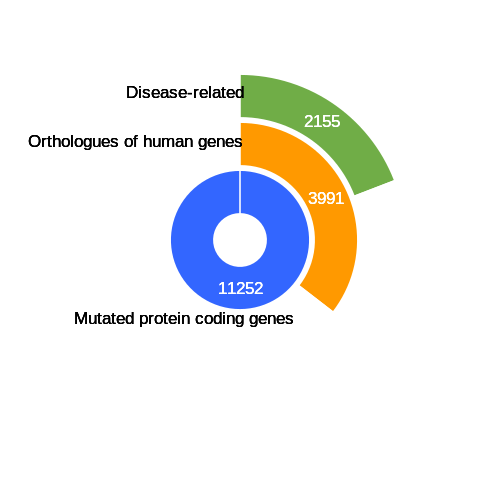

In [ ]:
%%R
#@title Ratio of disease-related genes
library(ggplot2)
txtsz<-6

table<-read.csv("/content/dataset/genedis.csv",row.names=1)

df <- data.frame(
  ring = c(1,1,2,2,3,3),
  label = c("Mutated protein coding genes","Z","Orthologues of human genes","Z","Disease-related","Z"),
  value = c(table[1,2],0,table[2,2],table[1,2]-table[2,2],table[3,2],table[1,2]-table[3,2])
)
df$ilabel <- df$label[1]
df$inum <- table[1,2]
df$mlabel <- df$label[3]
df$mnum <- table[2,2]
df$olabel <- df$label[5]
df$onum <- table[3,2]
df$alpha <- ifelse(df$label=="Z", 0.0, 1)
ggplot(df, aes(ring, value, fill=label, alpha=alpha)) +
     geom_bar(stat="identity", width=0.9, color="white") +
     geom_text(aes(x=2.0,y=table[1,2]*40/100,label=ilabel), size=txtsz, color="black") +
     geom_text(aes(x=1.0,y=table[1,2]/2,label=inum), size=txtsz, color="white") +
     geom_text(aes(x=3.0,y=(table[1,2]-table[2,2])*20/100,label=mlabel), size=txtsz, color="black") +
     geom_text(aes(x=2.0,y=table[1,2]-table[2,2]/2,label=mnum), size=txtsz, color="white") +
     geom_text(aes(x=3.3,y=(table[1,2]-table[3,2])*7/100,label=olabel), size=txtsz, color="black") +
     geom_text(aes(x=3.0,y=table[1,2]-table[3,2]/2,label=onum), size=txtsz, color="white") +
     scale_fill_manual(
         values = c(
             "Mutated protein coding genes" = "#3366FF",
             "Orthologues of human genes" = "#FF9900",
             "Disease-related" = "#70AD47"
         )
     ) +
     coord_polar(theta="y", direction=-1) +
     xlim(0,4) +
     theme_void() +
     theme(legend.position = "none") +
     scale_alpha_identity()

In [ ]:
#@title Usage of mutants for disease-related gene orthologues
usage = {}
for label in ref_label:
  refs = []
  related = []
  for refid in ref_label[label]:
    refs.append(refid)
    genes = []
    for mut in used_alleles[str(refid)]:
      if mut in m2g:
        genes.extend(m2g[mut])
    genes = list(set(genes))
    diseases = []
    for wg in genes:
      if wg in ortho:
        for hg in ortho[wg]:
          if hg in g2d:
            diseases.extend(g2d[hg])
    diseases = list(set(diseases))
    if 0 < len(diseases):
      related.append(refid)

  usage[label] = {
      'Total':len(refs),
      'DiseaseRelated':len(related)
  }

usageDF = pd.DataFrame(usage)
display(usageDF)
usageDF.to_csv('/content/dataset/usedgene.csv')

,1999,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Total,1,1,2,10,13,56,90,117,150,167,...,252,247,230,266,227,195,279,286,232,240
DiseaseRelated,1,1,0,4,6,31,42,60,81,82,...,147,146,126,151,127,116,171,168,130,139


# Pathway views

In [ ]:
%%R
#@title Export pathways
kgids <- read.csv('/content/dataset/keggID.csv',header=F)
kgids <- kgids[,2]

targetIDs<-c("cel03018","cel04140","cel04137","cel00600","cel04068","cel04212","cel04361","cel04082")

setwd('/content/dataset/images')
for (pathway in targetIDs) {
  pathview(
    gene.data = kgids,
         gene.idtype = "KEGG",
         pathway.id = pathway,
         species = 'Caenorhabditis elegans',
         out.suffix = 'pathview'
  )
}

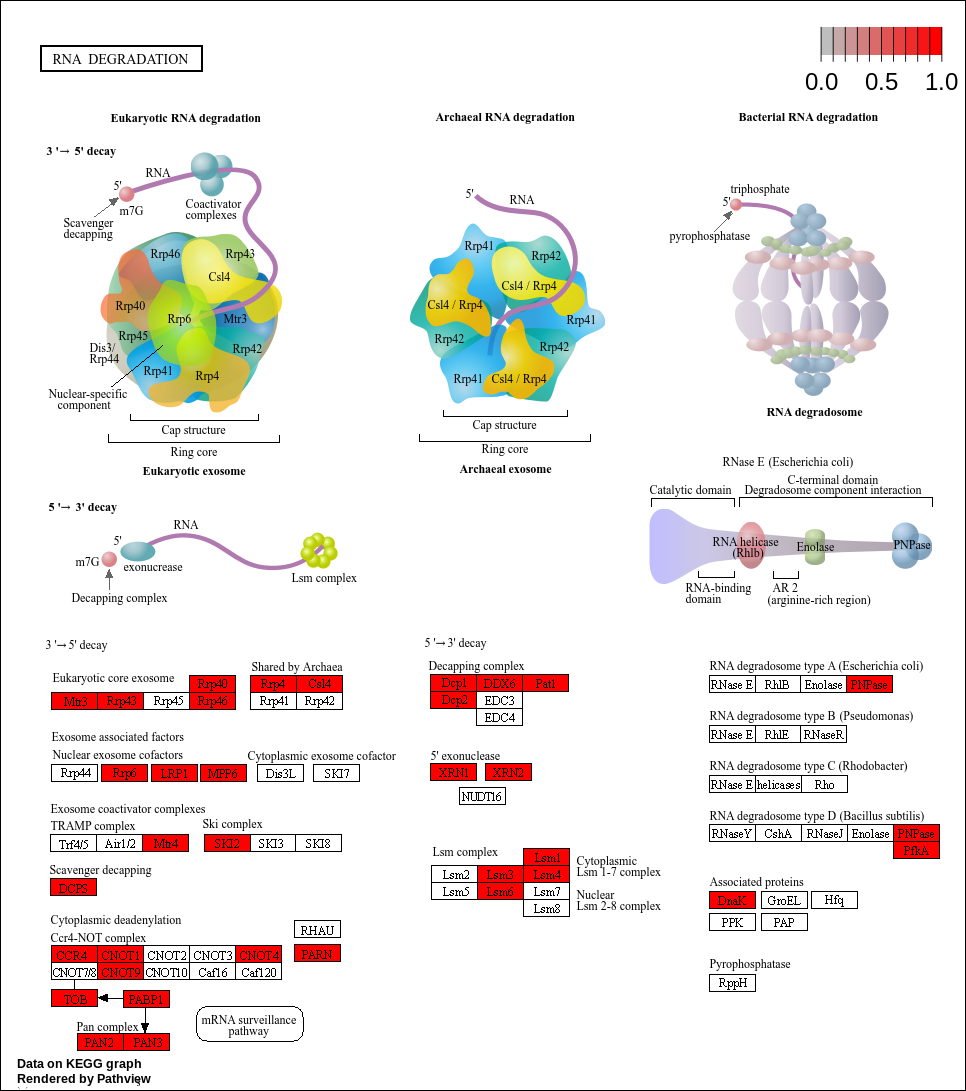

In [ ]:
#@title RNA Degradation pathview
display(Image('/content/dataset/images/cel03018.pathview.png'))


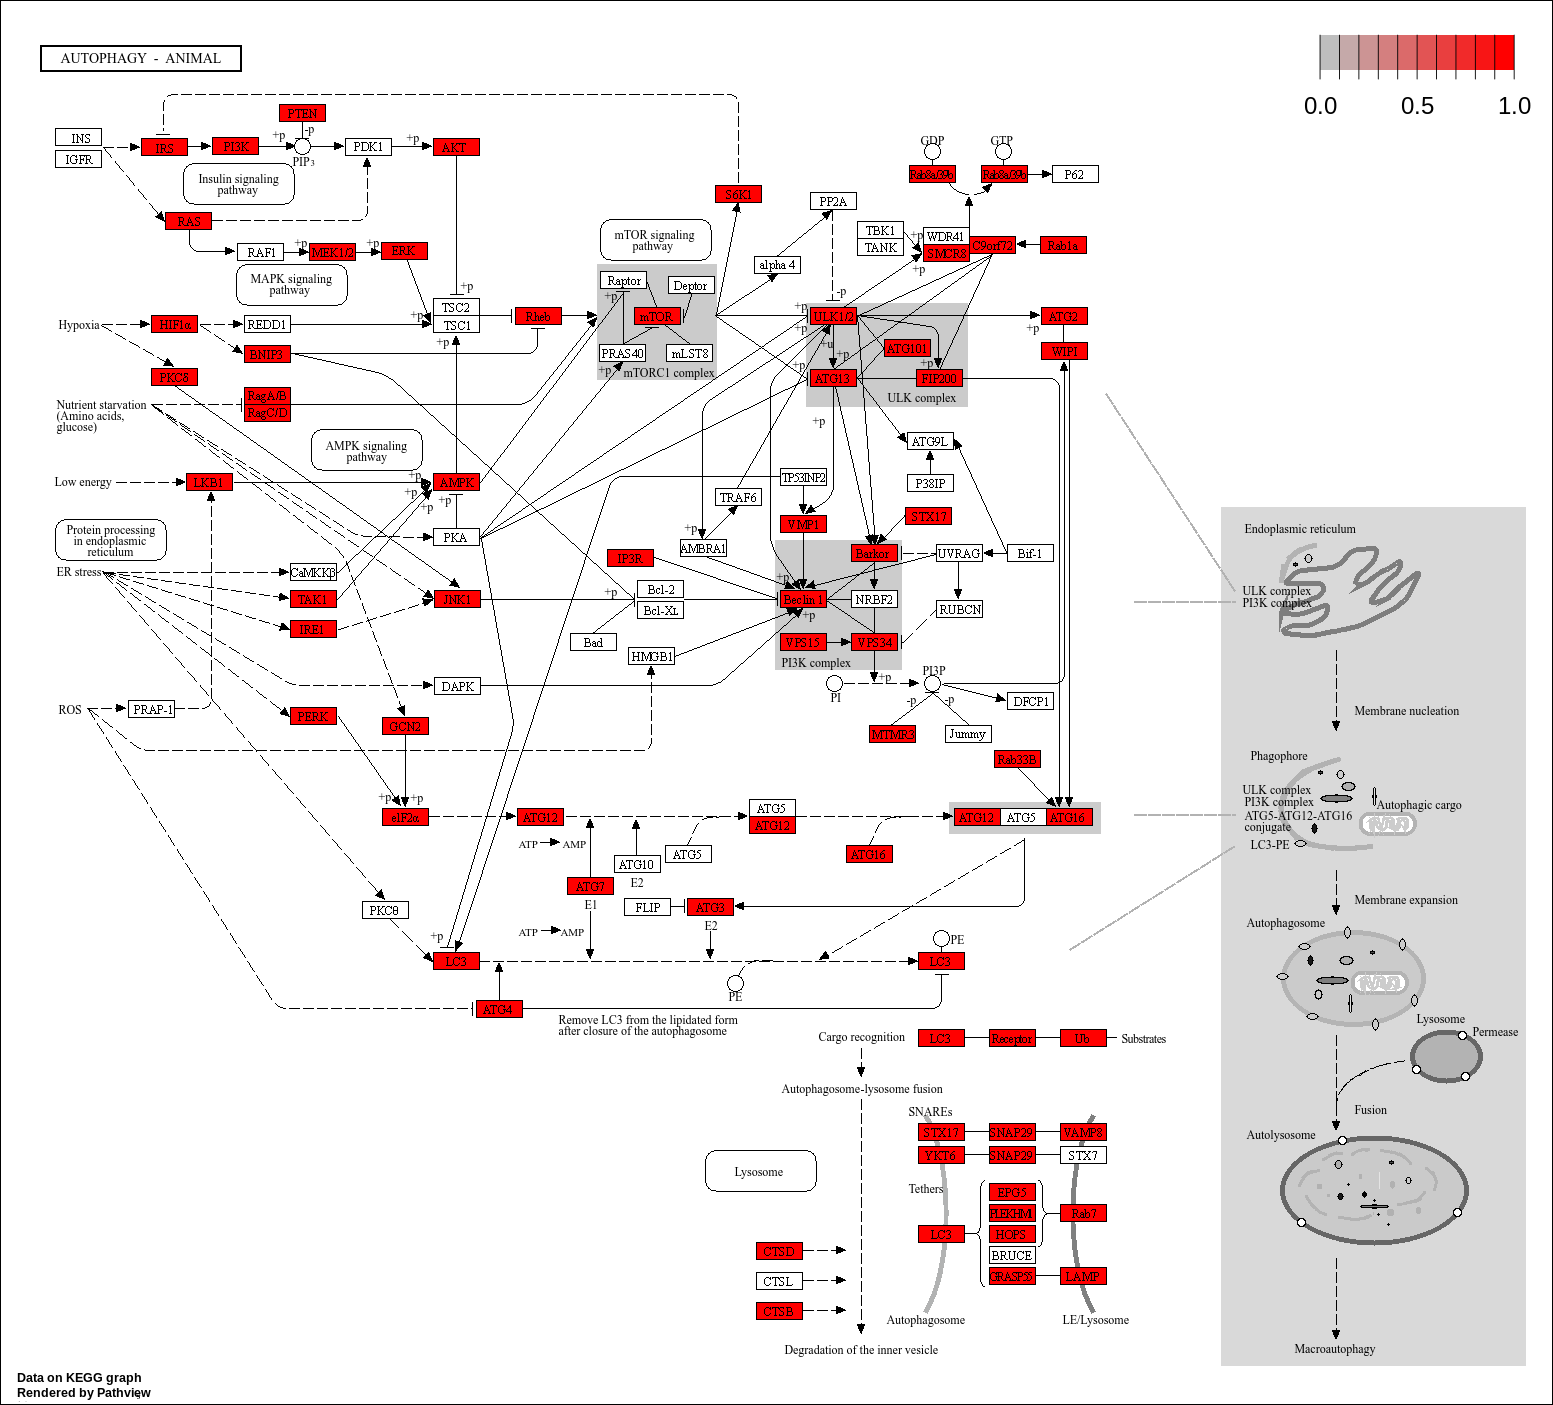

In [ ]:
#@title Autophagy pathview
display(Image('/content/dataset/images/cel04140.pathview.png'))


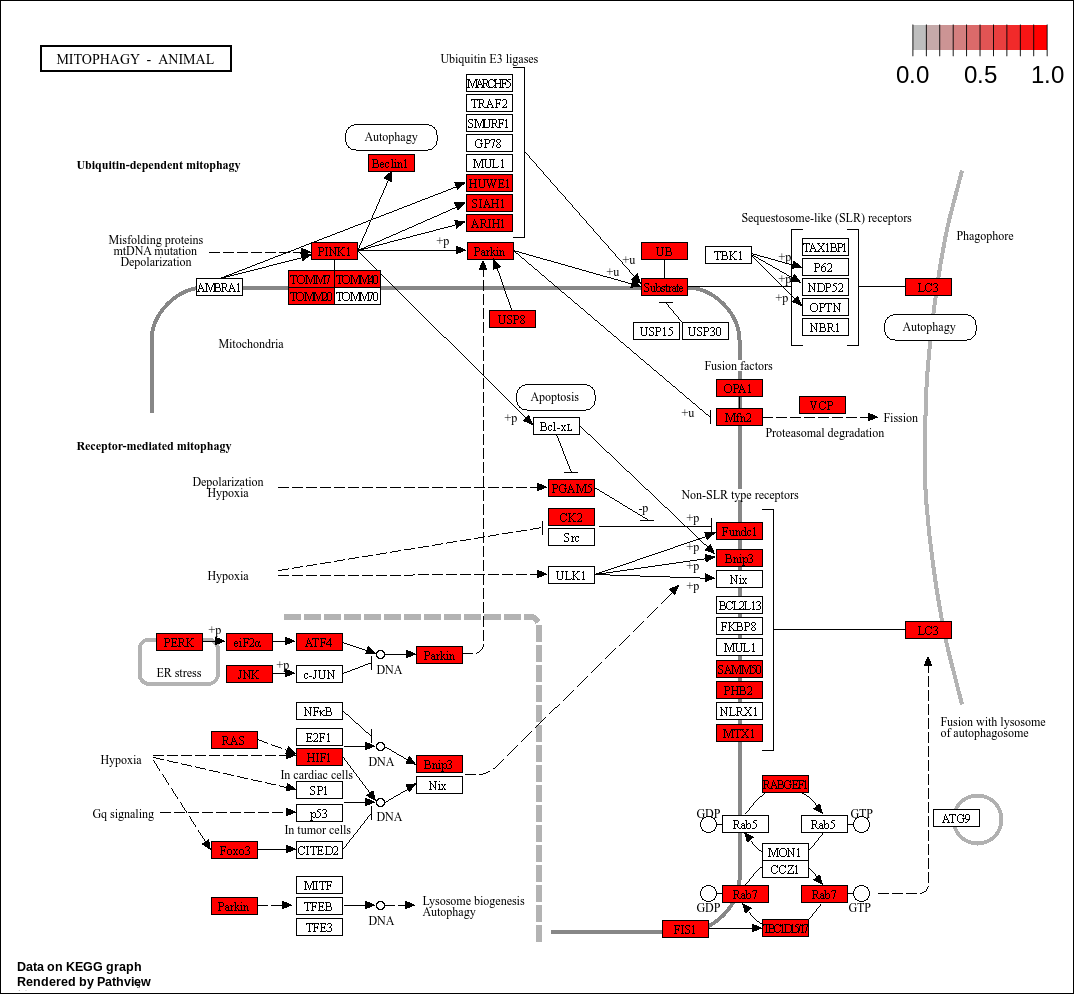

In [ ]:
#@title Mitophagy pathview
display(Image('/content/dataset/images/cel04137.pathview.png'))


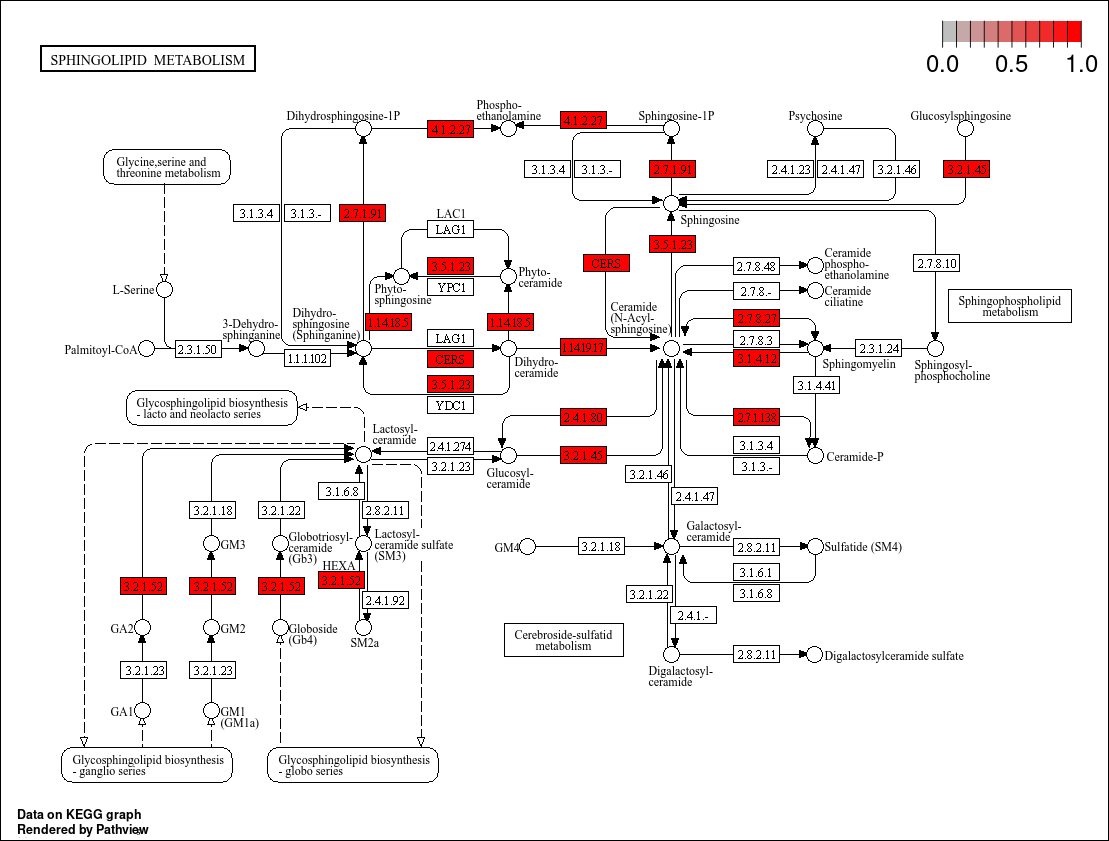

In [ ]:
#@title Lipid Metabolism pathview
display(Image('/content/dataset/images/cel00600.pathview.png'))


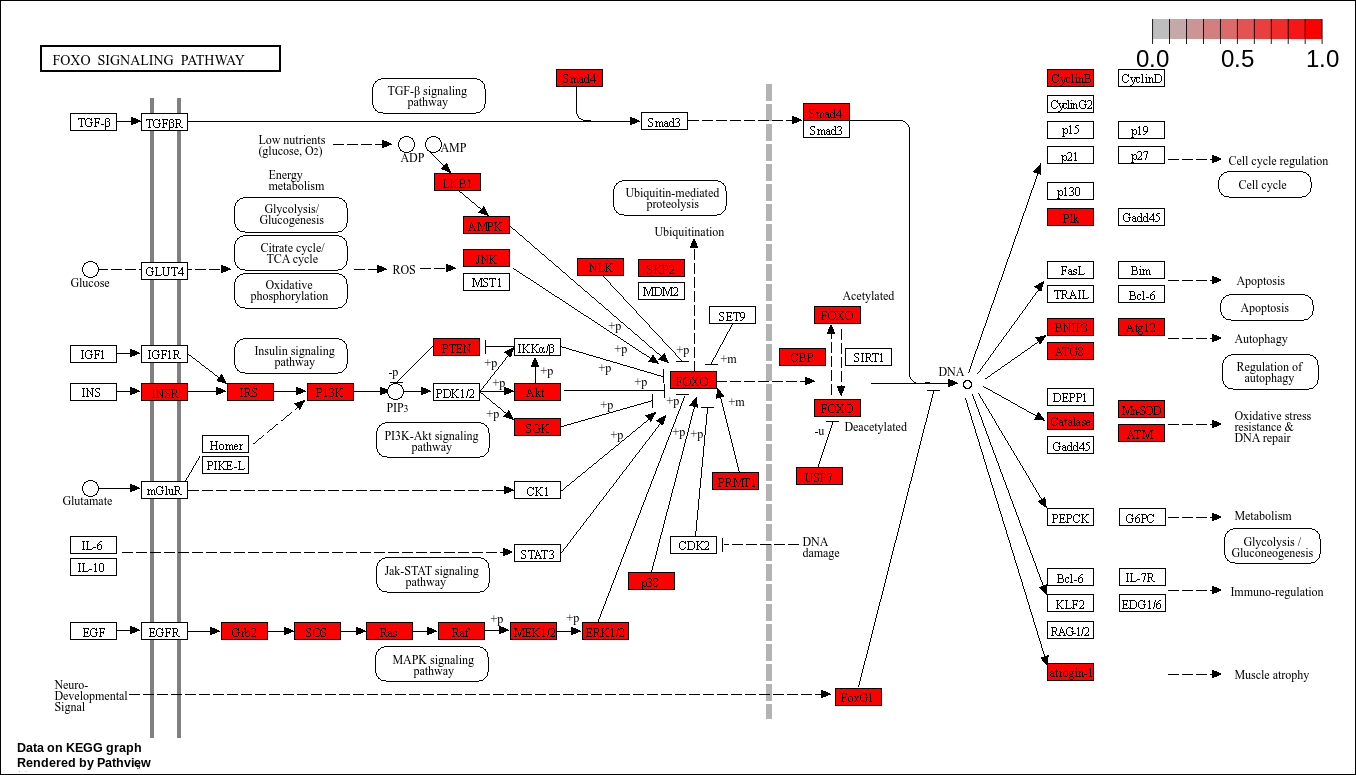

In [ ]:
#@title IIS/Foxo pathview
display(Image('/content/dataset/images/cel04068.pathview.png'))


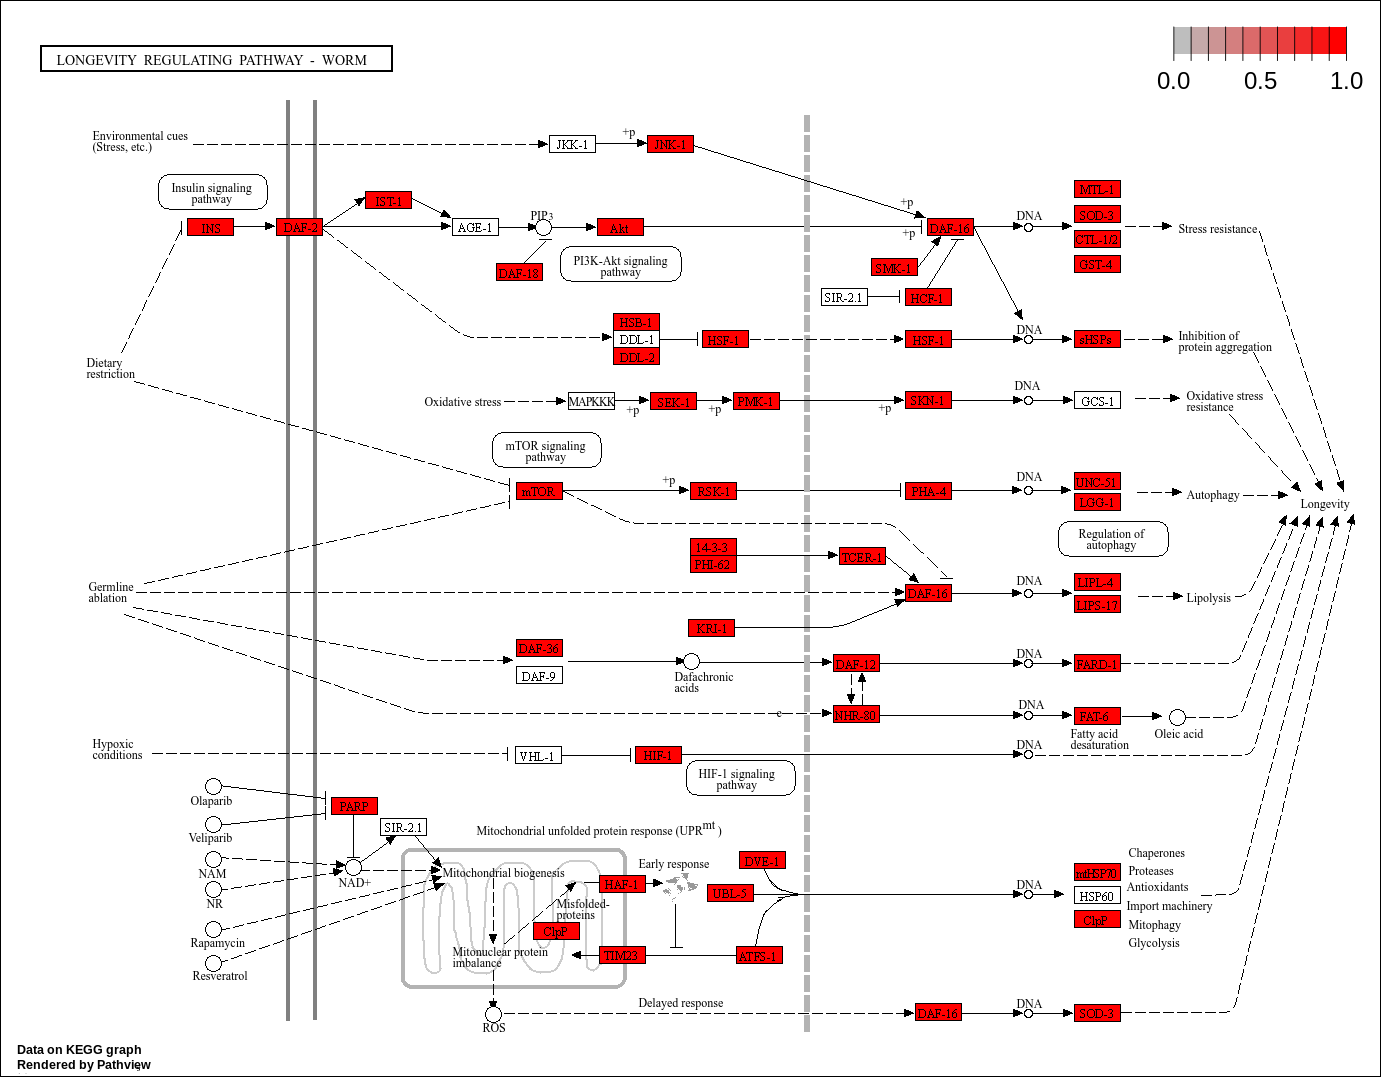

In [ ]:
#@title Longevity pathview
display(Image('/content/dataset/images/cel04212.pathview.png'))


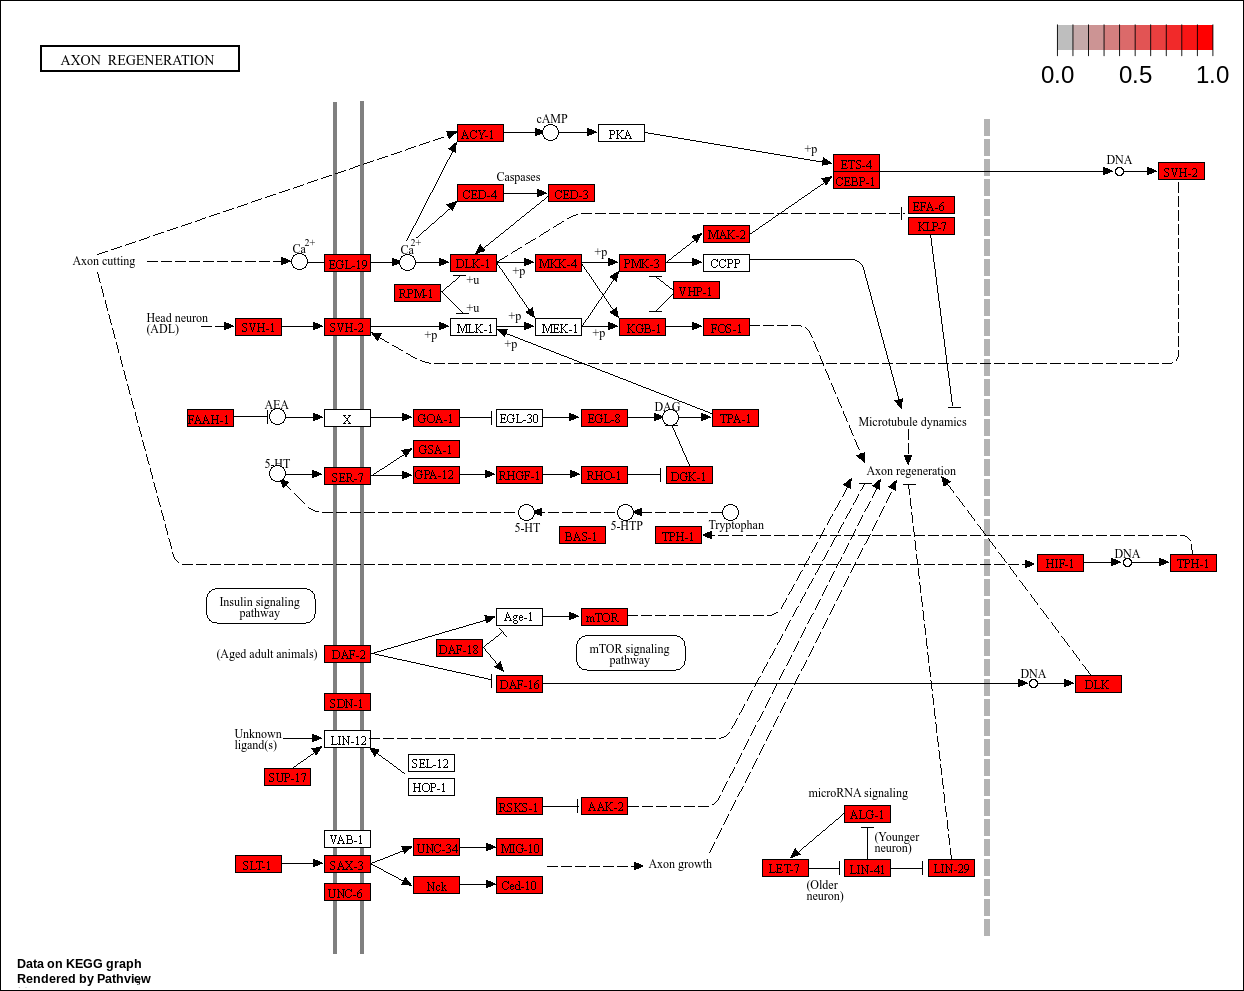

In [ ]:
#@title Neuroregeneration pathview
display(Image('/content/dataset/images/cel04361.pathview.png'))


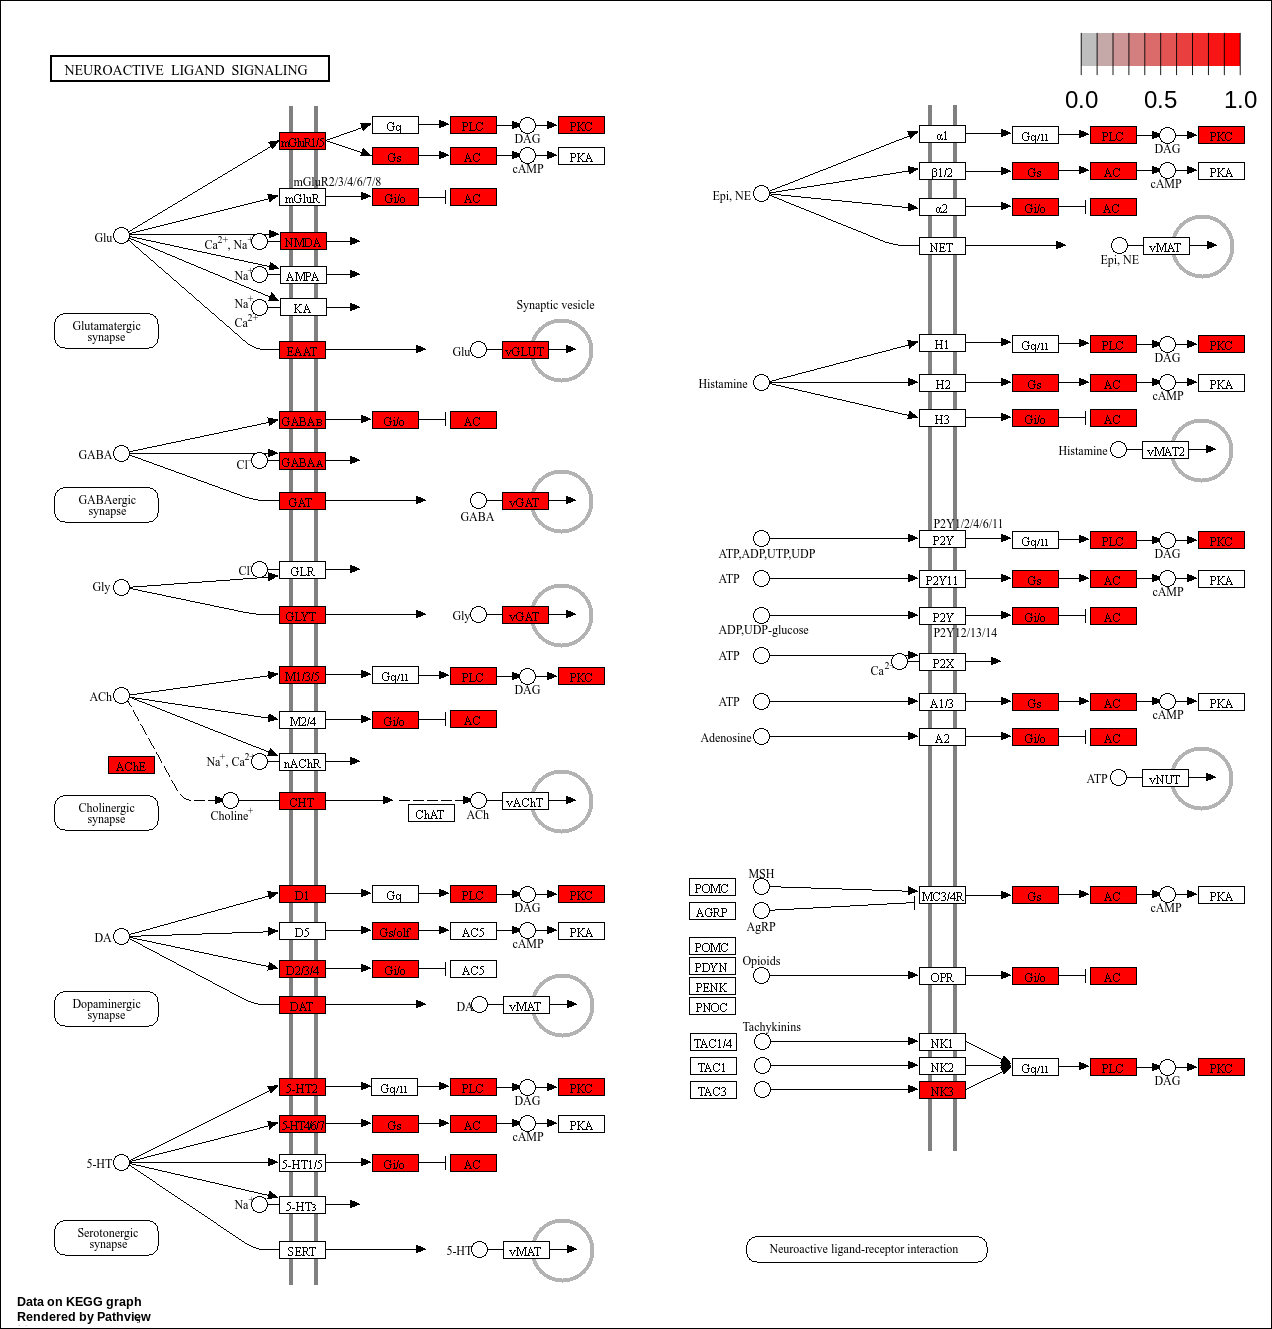

In [ ]:
#@title Neural Signaling pathview
display(Image('/content/dataset/images/cel04082.pathview.png'))
